**1- Lee los datos para la actividad 1**

**Código para visualizar cómodamente los datos en segmentos de filas indicadas.**



In [ ]:
#instalar librerias necesarias
!pip install ipywidgets
!pip install colorama

In [2]:
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

def display_data_in_chunks(data, chunk_size=10):
    """
    Visualiza los datos en segmentos para facilitar su visualización.

    Esta función muestra los datos en segmentos definidos por chunk_size,
    y permite al usuario ver más datos presionando un botón "Next". Cada vez
    que se presiona el botón, se muestra el siguiente segmento de datos hasta
    que no haya más datos para mostrar.

    Args:
    data (pd.DataFrame): El DataFrame que contiene los datos a visualizar.
    chunk_size (int): El número de filas a mostrar por segmento. Por defecto es 10.
    """

    start_row = 0
    end_row = chunk_size

    # Crear un contenedor para la salida
    output = widgets.Output()
    display(output)

    def show_next_chunk(b):
        """
        Función interna para manejar la interacción del botón.

        Esta función muestra el siguiente segmento de datos cuando se
        presiona el botón "Next". Actualiza la visualización y controla
        el final de los datos.

        Args:
        b: El botón que desencadena la función.
        """
        nonlocal start_row, end_row
        with output:
            clear_output(wait=True)
            if start_row < len(data):
                display(HTML(data[start_row:end_row].to_html()))
                start_row += chunk_size
                end_row += chunk_size
                if end_row > len(data):
                    end_row = len(data)
            if start_row >= len(data):
                button_next.layout.display = 'none'

    # Crear el botón "Next"
    button_next = widgets.Button(description="Next", layout=widgets.Layout(width='60px'))
    button_next.on_click(show_next_chunk)

    # Mostrar el primer segmento y el botón
    with output:
        display(HTML(data[start_row:end_row].to_html()))
    start_row += chunk_size
    end_row += chunk_size
    display(button_next)


In [3]:
import pandas as pd

# Cargar *.csv
#file_path = '/content/drive/MyDrive/dataScience/analisis_datos/datos_actividad_01.csv'
#datos_actividad_1 = pd.read_csv(file_path, usecols=[0, 1, 2])

# Cargar *.xlsx
file_path = '/content/drive/MyDrive/dataScience/analisis_datos/semana_01/Datos Actividad 1.xlsx'
datos_actividad_1 = pd.read_excel(file_path, usecols=[0, 1, 2])

#Descartamos espacios vacios .dropna()
# Datos columna Nation
nation = datos_actividad_1['Nation'].dropna()
# Datos columna HDI 2021
hdi_2021_data = datos_actividad_1['HDI 2021'].dropna()
# Datos columna Average annual growth(2010–2021) multiplicar los datos * 100
average_data = datos_actividad_1['Average annual growth(2010–2021)​'].dropna()*100

#Añadimos los datos de average con la multiplicación por 100
datos_actividad_1_edit = pd.DataFrame({
    'Nation': nation,
    'HDI 2021': hdi_2021_data,
    'Average annual growth (2010–2021)': average_data
})

#print(nation)
#print(average_data)
#print(hdi_2021_data)

# Mostrar los datos en segmentos
display_data_in_chunks(datos_actividad_1_edit, 10)




Output()

Button(description='Next', layout=Layout(width='60px'), style=ButtonStyle())

**2-Histograma de los datos columna HDI 2021**

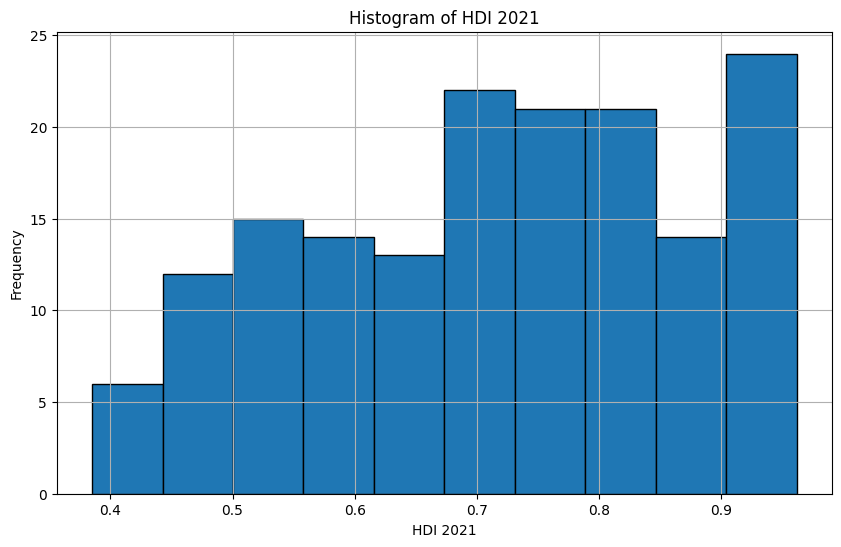

In [4]:
#print(nation)
#print(hdi_2021_data)
#print(average_data)
# Importar matplotlib para la visualización
import matplotlib.pyplot as plt

# Crear y visualizar el histograma de la columna 'HDI 2021'
plt.figure(figsize=(10, 6))
plt.hist(hdi_2021_data, bins=10, edgecolor='k')
plt.xlabel('HDI 2021')
plt.ylabel('Frequency')
plt.title('Histogram of HDI 2021')
plt.grid(True)
plt.show()

**2-Histograma de los datos columna Average annual growth(2010–2021)**

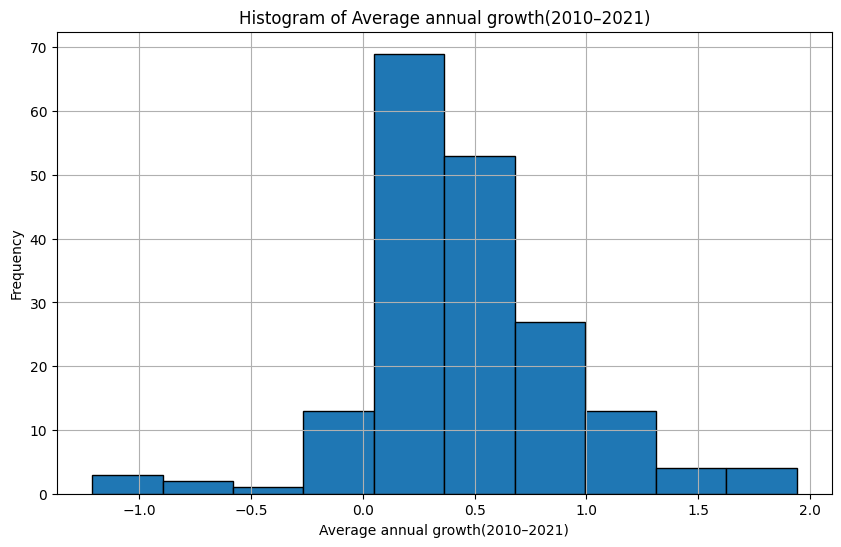

In [5]:

# Crear y visualizar el histograma de la columna 'Average annual growth(2010–2021)​'
plt.figure(figsize=(10, 6))
plt.hist(average_data, bins=10, edgecolor='k')
plt.xlabel('Average annual growth(2010–2021)​')
plt.ylabel('Frequency')
plt.title('Histogram of Average annual growth(2010–2021)​')
plt.grid(True)
plt.show()


**3-Genera un gráfico de densidad para HDI 2021**

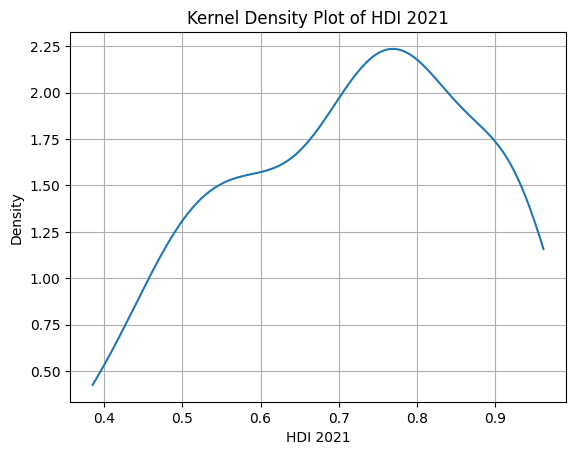

In [6]:
# Crear y visualizar el gráfico de densidad de 'HDI 2021​'
from scipy.stats import gaussian_kde
import numpy as np
density = gaussian_kde(hdi_2021_data)
xs = np.linspace(hdi_2021_data.min(), hdi_2021_data.max(), 200)
ys = density(xs)
plt.plot(xs, ys)
plt.xlabel('HDI 2021')
plt.ylabel('Density')
plt.title('Kernel Density Plot of HDI 2021')
plt.grid(True)
plt.show()

**3-Genera un gráfico de densidad para Average annual growth(2010–2021)**

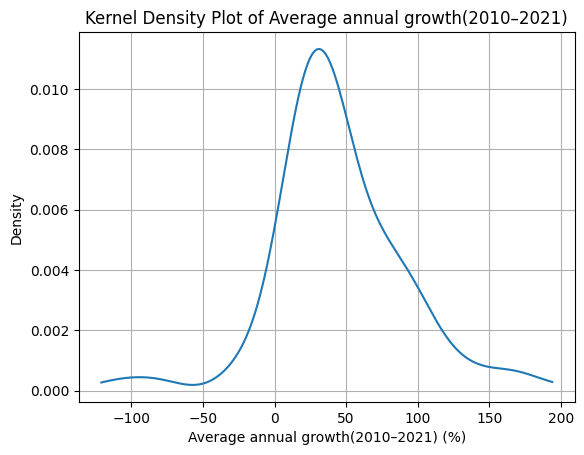

In [7]:
# Crear y visualizar el gráfico de densidad de 'Average annual growth(2010–2021)​'
density = gaussian_kde(average_data * 100)  # Multiplicación por 100 para convertir a porcentaje
xs = np.linspace((average_data * 100).min(), (average_data * 100).max(), 200)
ys = density(xs)
plt.plot(xs, ys)
plt.xlabel('Average annual growth(2010–2021) (%)')
plt.ylabel('Density')
plt.title('Kernel Density Plot of Average annual growth(2010–2021)')
plt.grid(True)
plt.show()

**4-Calcula la media, mediana, desviación estándar, coeficiente de variación, rango intercuartil, los distintos cuartiles, el máximo y mínimo de las variables HDI 2021 y Average annual growth(2010–2021). En este caso hay valores vacíos (NAs). Por tanto, deberéis ignorar dichos valores.**

In [12]:

hdi_2021_media = hdi_2021_data.mean()
hdi_2021_mediana = hdi_2021_data.median()
hdi_2021_desviacion_estandar = hdi_2021_data.std()
hdi_2021_coeficiente_variacion = hdi_2021_data.std() / hdi_2021_data.mean()
hdi_2021_IQR = hdi_2021_data.quantile(0.75) - hdi_2021_data.quantile(0.25)
hdi_2021_Q1 = hdi_2021_data.quantile(0.25)
hdi_2021_Q2 = hdi_2021_data.quantile(0.50)
hdi_2021_Q3 = hdi_2021_data.quantile(0.75)
hdi_2021_min = hdi_2021_data.min()
hdi_2021_max = hdi_2021_data.max()
hdi_2021_rango = hdi_2021_max - hdi_2021_min

average_data_media = average_data.mean()
average_data_mediana = average_data.median()
average_data_desviacion_estandar = average_data.std()
average_data_coeficiente_variacion = average_data.std() / average_data.mean()
average_data_IQR = average_data.quantile(0.75) - average_data.quantile(0.25)
average_data_Q1 = average_data.quantile(0.25)
average_data_Q2 = average_data.quantile(0.50)
average_data_Q3 = average_data.quantile(0.75)
average_data_min = average_data.min()
average_data_max = average_data.max()
average_data_rango = average_data_max - average_data_min

# Calcular y mostrar las estadísticas de HDI 2021
print('Media de HDI 2021: ', hdi_2021_media)
print('Mediana de HDI 2021: ', hdi_2021_mediana)
print('Desviación estándar de HDI 2021: ', hdi_2021_desviacion_estandar)
print('Coeficiente de variación de HDI 2021: ', hdi_2021_coeficiente_variacion)
print('Rango intercuartil de HDI 2021: ', hdi_2021_IQR)
print('Q1 de HDI 2021: ', hdi_2021_Q1)
print('Q2 (mediana) de HDI 2021: ', hdi_2021_Q2)
print('Q3 de HDI 2021: ', hdi_2021_Q3)
print('Valor mínimo de HDI 2021: ', hdi_2021_min)
print('Valor máximo de HDI 2021: ', hdi_2021_max)
print('Valor rango: ', hdi_2021_rango)

print("\n")

# Calcular y mostrar las estadísticas de Average annual growth(2010–2021)
print('Media Average annual growth(2010–2021): ', average_data_media)
print('Mediana Average annual growth(2010–2021): ', average_data_mediana)
print('Desviación Average annual growth(2010–2021): ', average_data_desviacion_estandar)
print('Coeficiente de variación Average annual growth(2010–2021): ', average_data_coeficiente_variacion)
print('Rango intercuartil Average annual growth(2010–2021): ', average_data_IQR)
print('Q1 Average annual growth(2010–2021): ', average_data_Q1)
print('Q2 (mediana) Average annual growth(2010–2021): ', average_data_Q2)
print('Q3 Average annual growth(2010–2021): ', average_data_Q3)
print('Valor mínimo Average annual growth(2010–2021): ', average_data_min)
print('Valor máximo Average annual growth(2010–2021): ', average_data_max)
print('Valor rango: ', average_data_rango)

Media de HDI 2021:  0.7160987654320987
Mediana de HDI 2021:  0.7304999999999999
Desviación estándar de HDI 2021:  0.15605096356088302
Coeficiente de variación de HDI 2021:  0.21791821337203512
Rango intercuartil de HDI 2021:  0.24875000000000003
Q1 de HDI 2021:  0.58775
Q2 (mediana) de HDI 2021:  0.7304999999999999
Q3 de HDI 2021:  0.8365
Valor mínimo de HDI 2021:  0.385
Valor máximo de HDI 2021:  0.962
Valor rango:  0.577


Media Average annual growth(2010–2021):  0.44634920634920633
Mediana Average annual growth(2010–2021):  0.38999999999999996
Desviación Average annual growth(2010–2021):  0.4585765496341552
Coeficiente de variación Average annual growth(2010–2021):  1.0273941190238896
Rango intercuartil Average annual growth(2010–2021):  0.5
Q1 Average annual growth(2010–2021):  0.2
Q2 (mediana) Average annual growth(2010–2021):  0.38999999999999996
Q3 Average annual growth(2010–2021):  0.7000000000000001
Valor mínimo Average annual growth(2010–2021):  -1.21
Valor máximo Average ann

In [9]:

from colorama import Fore, Style
from tabulate import tabulate


# Valores estadísticas descriptivas
def calculate_statistics(data):
    statistics = {
        'Media': np.mean(data),
        'Mediana': np.median(data),
        'Desviación estándar': np.std(data, ddof=1),
        'Coeficiente de variación': np.std(data, ddof=1) / np.mean(data),
        'Rango intercuartil': np.percentile(data, 75) - np.percentile(data, 25),
        'Primer cuartil (Q1)': np.percentile(data, 25),
        'Segundo cuartil (Q2 - Median)': np.percentile(data, 50),
        'Tercer cuartil (Q3)': np.percentile(data, 75),
        'Valor mínimo': np.min(data),
        'Valor máximo': np.max(data)
    }
    return statistics

# Estadísticas para HDI 2021
hdi_2021_stats = calculate_statistics(hdi_2021_data)
# Estadísticas para Average annual growth(2010–2021)
average_stats = calculate_statistics(average_data)

# DataFrame resultados
statistics_df = pd.DataFrame({
    'HDI 2021': hdi_2021_stats,
    'Average annual growth(2010–2021)': average_stats
})

# Imprimir con tabulate
print(tabulate(statistics_df, headers='keys', tablefmt='fancy_grid', floatfmt=".6f"))


╒═══════════════════════════════╤════════════╤════════════════════════════════════╕
│                               │   HDI 2021 │   Average annual growth(2010–2021) │
╞═══════════════════════════════╪════════════╪════════════════════════════════════╡
│ Media                         │   0.716099 │                           0.446349 │
├───────────────────────────────┼────────────┼────────────────────────────────────┤
│ Mediana                       │   0.730500 │                           0.390000 │
├───────────────────────────────┼────────────┼────────────────────────────────────┤
│ Desviación estándar           │   0.156051 │                           0.458577 │
├───────────────────────────────┼────────────┼────────────────────────────────────┤
│ Coeficiente de variación      │   0.217918 │                           1.027394 │
├───────────────────────────────┼────────────┼────────────────────────────────────┤
│ Rango intercuartil            │   0.248750 │                           0.5

**5-Sacad conclusiones a partir de los resultados de las tareas 2 - 4.**



**HDI 2021**

La coincidencia entre la **media = 0.716** y la **mediana = 0.73** indica que la mayoría de los países tuvieron un HDI en 2021 muy similar. El histograma muestra que hay más países con un HDI alto que bajo. Sin embargo, la diferencia entre el dato mayor y menor **rango = 0.577** señala una discrepancia de más de la mitad entre el país con el HDI más alto y el país con el HDI más bajo, lo que alerta sobre las grandes diferencias en los extremos.

En cuanto al grueso de los países, la **desviación estándar = 0.156** y el coeficiente de **variación = 0.217** son bajos, lo que indica poca variabilidad en la mayoría. Un rango **intercuartílico = 0.248** bajo también confirma esto.

**Average Annual Growth (2010-2021)**

La **media = 0.446** y la **mediana = 0.39**, lo que sugiere que la mayoría de los países han tenido un crecimiento similar en su HDI durante este período. Sin embargo, la distribución no es perfectamente simétrica, ya que hay algunos países con tasas de crecimiento muy altas que están elevando la media esto no lo indica el **rango =3.15** revela una considerable discrepancia entre el país con el mayor crecimiento y el país con el menor crecimiento, lo que destaca las grandes diferencias en los extremos.

El histograma muestra una mayor dispersión en comparación con el HDI 2021, indicando que las tasas de crecimiento varían significativamente entre los países.

Para el grueso de los países, la desviación **estándar = 0.459** y el **coeficiente de variación  = 1.027** son relativamente altos, indicando una mayor variabilidad en las tasas de crecimiento. Un **rango intercuartílico = 0.5** más amplio confirma esta variabilidad, lo cual es esperable dada la diversidad de contextos económicos y sociales en los distintos países.